In [3]:
import pandas as pd
import numpy as np
import sys
from xgboost import XGBClassifier
from sklearn.multioutput import ClassifierChain
from sklearn.metrics import classification_report, f1_score, hamming_loss, accuracy_score
import time
from pathlib import Path
import mlflow
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
from sklearn.model_selection import train_test_split

pd.set_option('display.max_rows', None)

# ==========================================
# 0. MLFLOW SETUP
# ==========================================
root_path = Path.cwd().parent
import os
import json
from dotenv import load_dotenv
load_dotenv(dotenv_path=root_path / ".env") # Load variabel dari .env
# Gunakan DagsHub URI jika ada di .env, jika tidak pakai folder lokal mlruns
tracking_uri = os.getenv("MLFLOW_TRACKING_URI", (root_path / "mlruns").as_uri())
mlflow.set_tracking_uri(tracking_uri)
mlflow.set_experiment("07e_Baseline_XGBoost_AllFeatures")

# ==========================================
# 1. LOAD DATA
# ==========================================
print("🔍 1. Memuat dataset...")
train_balanced = pd.read_csv(root_path / "Data/processed/train_balanced_multilabel.csv")
train_ori = pd.read_csv(root_path / "Data/split/train_data.csv")
test_data = pd.read_csv(root_path / "Data/split/test_data.csv")

target_cols = ['risk_depression', 'risk_anxiety', 'risk_stress']

X_train = train_balanced.drop(columns=target_cols)
y_train = train_balanced[target_cols].astype(int)

X_train_ori = train_ori.drop(columns=target_cols)
y_train_ori = train_ori[target_cols].astype(int)

X_test  = test_data.drop(columns=target_cols)
y_test  = test_data[target_cols].astype(int)

# Samakan kolom
X_train_ori = X_train_ori.reindex(columns=X_train.columns, fill_value=0)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

num_features = X_train.shape[1]
print(f"✓ Jumlah fitur (SEMUA - Tanpa Seleksi): {num_features} fitur")
print(f"✓ Data Train SMOTE shape: {X_train.shape}")
print(f"✓ Data Train Asli shape : {X_train_ori.shape}")
print(f"✓ Data Test shape       : {X_test.shape}")

# Split data ASLI → Train_sub + Validation (untuk kalibrasi threshold)
print("\n🔀 Split Data Asli → Train_sub & Validation (80-20) untuk kalibrasi threshold...")
X_train_sub_ori, X_val_ori, y_train_sub_ori, y_val_ori = train_test_split(
    X_train_ori, y_train_ori, test_size=0.2, random_state=42
)
print(f"   ✓ Train sub (asli) : {X_train_sub_ori.shape}")
print(f"   ✓ Validation (asli): {X_val_ori.shape}")

# ==========================================
# 2. HELPER FUNCTIONS
# ==========================================
def find_optimal_thresholds(model, X_data, Y_data, targets, step=0.01):
    """Mencari threshold optimal per target class."""
    print("\n   Mengambil probabilitas dari data validasi...")
    n_samples  = X_data.shape[0]
    n_targets  = len(targets)
    all_probas = np.zeros((n_samples, n_targets))

    X_aug = X_data.values.copy() if hasattr(X_data, 'values') else X_data.copy()

    for i, estimator in enumerate(model.estimators_):
        proba = estimator.predict_proba(X_aug)[:, 1]
        all_probas[:, i] = proba
        pred_label = (proba >= 0.5).astype(int).reshape(-1, 1)
        X_aug = np.hstack([X_aug, pred_label])

    best_thresholds = []
    print(f"\n   {'Target':<20} {'Threshold':>10} {'Val F1':>10}")
    print(f"   {'-'*42}")

    for i, target_name in enumerate(targets):
        best_t  = 0.5
        best_f1 = 0.0
        for t in np.arange(0.1, 0.9, step):
            y_pred_temp = (all_probas[:, i] >= t).astype(int)
            f1 = f1_score(
                Y_data.iloc[:, i] if hasattr(Y_data, 'iloc') else Y_data[:, i],
                y_pred_temp, zero_division=0
            )
            if f1 > best_f1:
                best_f1 = f1
                best_t  = t
        best_thresholds.append(round(best_t, 2))
        print(f"   {target_name:<20} {best_t:>10.2f} {best_f1:>10.4f}")

    return best_thresholds


def apply_thresholds(model, X_data, thresholds, targets):
    """Menerapkan threshold kustom ke prediksi."""
    n_samples  = X_data.shape[0]
    n_targets  = len(targets)
    all_probas = np.zeros((n_samples, n_targets))

    X_aug = X_data.values.copy() if hasattr(X_data, 'values') else X_data.copy()

    for i, estimator in enumerate(model.estimators_):
        proba = estimator.predict_proba(X_aug)[:, 1]
        all_probas[:, i] = proba
        pred_label = (proba >= thresholds[i]).astype(int).reshape(-1, 1)
        X_aug = np.hstack([X_aug, pred_label])

    y_pred_optimized = np.zeros((n_samples, n_targets), dtype=int)
    for i in range(n_targets):
        y_pred_optimized[:, i] = (all_probas[:, i] >= thresholds[i]).astype(int)

    return y_pred_optimized


def evaluate_predictions(y_true, y_pred, label=""):
    """Hitung semua metrik evaluasi."""
    macro_f1    = f1_score(y_true, y_pred, average='macro', zero_division=0)
    micro_f1    = f1_score(y_true, y_pred, average='micro', zero_division=0)
    hamming     = hamming_loss(y_true, y_pred)
    exact_match = accuracy_score(y_true, y_pred)
    return {
        "label":        label,
        "Macro_F1":     macro_f1,
        "Micro_F1":     micro_f1,
        "Hamming_Loss": hamming,
        "Exact_Match":  exact_match,
    }

# ==========================================
# 3. INISIALISASI MODEL
# ==========================================
# Load parameter XGBoost yang sudah di-tuned (apple-to-apple dengan 11_final_model)
params_path = root_path / "models" / "best_xgb_params.json"
with open(params_path, "r") as f:
    xgb_params = json.load(f)
print(f"   Loaded tuned params: {xgb_params}")

print("\n🔧 2. Inisialisasi XGBoost dengan parameter standardized:")
for k, v in xgb_params.items():
    print(f"   - {k}: {v}")

# ==========================================
# 4. TRAINING MODEL UTAMA (Data SMOTE)
# ==========================================
print(f"\n⏳ 3. Training MODEL UTAMA di data SMOTE ({num_features} ALL Features)...")
start_time = time.time()
base_xgb = XGBClassifier(**xgb_params)
chain_model = ClassifierChain(base_xgb, order='random', random_state=42)
chain_model.fit(X_train, y_train)
training_time = time.time() - start_time
print(f"   ✓ Model utama selesai dalam {training_time:.2f} detik.")

# ==========================================
# 5. TRAINING MODEL SEMENTARA (Data Asli, untuk kalibrasi threshold)
# ==========================================
print("\n🔧 Training model sementara di 80% data asli untuk kalibrasi threshold...")
base_xgb_temp = XGBClassifier(**xgb_params)
temp_chain = ClassifierChain(base_xgb_temp, order='random', random_state=42)
temp_chain.fit(X_train_sub_ori, y_train_sub_ori)
print("   ✓ Model sementara selesai dilatih")

# ==========================================
# 6. EVALUASI DEFAULT (THRESHOLD 0.5)
# ==========================================
print("\n📊 4. Prediksi dengan threshold default (0.5)...")
y_pred_default = chain_model.predict(X_test)
results_default = evaluate_predictions(y_test, y_pred_default, "Default (0.5)")

# ==========================================
# 7. THRESHOLD OPTIMIZATION (dari model sementara + data validasi ASLI)
# ==========================================
print("\n🔍 5. Mencari threshold optimal dari data validasi ASLI...")
optimal_thresholds = find_optimal_thresholds(temp_chain, X_val_ori, y_val_ori, target_cols)
print(f"\n   Threshold optimal: {dict(zip(target_cols, optimal_thresholds))}")

# Buang model sementara
del temp_chain, base_xgb_temp
print("   ✓ Model sementara dibuang")

# ==========================================
# 8. EVALUASI DENGAN THRESHOLD OPTIMAL (pakai model UTAMA)
# ==========================================
print("\n📊 6. Prediksi dengan threshold optimal (model utama)...")
y_pred_optimized = apply_thresholds(chain_model, X_test, optimal_thresholds, target_cols)
results_optimized = evaluate_predictions(y_test, y_pred_optimized, "Optimized")

# ==========================================
# 9. TAMPILKAN HASIL PERBANDINGAN
# ==========================================
print("\n" + "="*70)
print("🏆 HASIL: XGBOOST ALL FEATURES + THRESHOLD OPTIMIZATION")
print("="*70)
print(f"{'Metrik':<25} {'Default (0.5)':>15} {'Optimized':>15} {'Δ':>10}")
print("-"*70)

for metric in ['Macro_F1', 'Micro_F1', 'Hamming_Loss', 'Exact_Match']:
    val_def  = results_default[metric]
    val_opt  = results_optimized[metric]
    delta    = val_opt - val_def
    arrow    = "↑" if delta > 0 else ("↓" if delta < 0 else "→")
    print(f"{metric:<25} {val_def:>15.4f} {val_opt:>15.4f} {arrow} {delta:>+.4f}")

print("="*70)
print(f"\nJumlah Fitur   : {num_features}")
print(f"Training Time  : {training_time:.2f} detik")
print(f"Threshold Optimal:")
for col, t in zip(target_cols, optimal_thresholds):
    print(f"   {col:<25}: {t:.2f}")

print("\n📋 CLASSIFICATION REPORT (Threshold Optimal):")
print(classification_report(
    y_test, y_pred_optimized,
    target_names=['Depression', 'Anxiety', 'Stress']
))

sys.stdout.flush()

# ==========================================
# 10. MLFLOW TRACKING
# ==========================================
print("\n📈 7. Tracking ke MLflow...")
with mlflow.start_run(run_name="XGBoost_AllFeatures_ThresholdOptimized"):
    mlflow.log_params(xgb_params)
    mlflow.log_param("feature_selection_method", "None - All Features")
    mlflow.log_param("multilabel_strategy", "ClassifierChain")
    mlflow.log_param("num_features", num_features)
    mlflow.log_param("threshold_calibration", "Data Asli (80-20 split)")

    # Metrik default
    mlflow.log_metric("Default_Macro_F1",     results_default['Macro_F1'])
    mlflow.log_metric("Default_Micro_F1",     results_default['Micro_F1'])
    mlflow.log_metric("Default_Hamming_Loss", results_default['Hamming_Loss'])
    mlflow.log_metric("Default_Exact_Match",  results_default['Exact_Match'])

    # Metrik optimized
    mlflow.log_metric("Optimized_Macro_F1",     results_optimized['Macro_F1'])
    mlflow.log_metric("Optimized_Micro_F1",     results_optimized['Micro_F1'])
    mlflow.log_metric("Optimized_Hamming_Loss", results_optimized['Hamming_Loss'])
    mlflow.log_metric("Optimized_Exact_Match",  results_optimized['Exact_Match'])

    for col, t in zip(target_cols, optimal_thresholds):
        mlflow.log_metric(f"Threshold_{col}", t)

    mlflow.log_metric("Training_Time_seconds", training_time)
    mlflow.log_dict(
        {"optimal_thresholds": dict(zip(target_cols, optimal_thresholds))},
        "07e_optimal_thresholds.json"
    )
    print("   ✓ MLflow tracking selesai!")

print("\n✅ Notebook eksekusi SELESAI!")


False

<Experiment: artifact_location='file:///d:/Website/Project-Data-Mining/backend/mlruns/708517929174754898', creation_time=1779651567209, experiment_id='708517929174754898', last_update_time=1779651567209, lifecycle_stage='active', name='07e_Baseline_XGBoost_AllFeatures', tags={}, trace_location=None, workspace='default'>

🔍 1. Memuat dataset...
✓ Jumlah fitur (SEMUA - Tanpa Seleksi): 19 fitur
✓ Data Train SMOTE shape: (8724, 19)
✓ Data Train Asli shape : (21740, 19)
✓ Data Test shape       : (5436, 19)

🔀 Split Data Asli → Train_sub & Validation (80-20) untuk kalibrasi threshold...
   ✓ Train sub (asli) : (17392, 19)
   ✓ Validation (asli): (4348, 19)
   Loaded tuned params: {'n_estimators': 400, 'max_depth': 4, 'learning_rate': 0.03, 'gamma': 0.2, 'colsample_bytree': 0.6667, 'subsample': 0.7667, 'min_child_weight': 5, 'eval_metric': 'logloss', 'random_state': 42, 'n_jobs': -1}

🔧 2. Inisialisasi XGBoost dengan parameter standardized:
   - n_estimators: 400
   - max_depth: 4
   - learning_rate: 0.03
   - gamma: 0.2
   - colsample_bytree: 0.6667
   - subsample: 0.7667
   - min_child_weight: 5
   - eval_metric: logloss
   - random_state: 42
   - n_jobs: -1

⏳ 3. Training MODEL UTAMA di data SMOTE (19 ALL Features)...


,estimator,"XGBClassifier...state=42, ...)"
,order,'random'
,cv,None
,chain_method,'predict'
,random_state,42
,verbose,False
,base_estimator,'deprecated'
,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None


   ✓ Model utama selesai dalam 2.68 detik.

🔧 Training model sementara di 80% data asli untuk kalibrasi threshold...


,estimator,"XGBClassifier...state=42, ...)"
,order,'random'
,cv,None
,chain_method,'predict'
,random_state,42
,verbose,False
,base_estimator,'deprecated'
,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None


   ✓ Model sementara selesai dilatih

📊 4. Prediksi dengan threshold default (0.5)...

🔍 5. Mencari threshold optimal dari data validasi ASLI...

   Mengambil probabilitas dari data validasi...

   Target                Threshold     Val F1
   ------------------------------------------
   risk_depression            0.45     0.8648
   risk_anxiety               0.34     0.8681
   risk_stress                0.61     0.8292

   Threshold optimal: {'risk_depression': np.float64(0.45), 'risk_anxiety': np.float64(0.34), 'risk_stress': np.float64(0.61)}
   ✓ Model sementara dibuang

📊 6. Prediksi dengan threshold optimal (model utama)...

🏆 HASIL: XGBOOST ALL FEATURES + THRESHOLD OPTIMIZATION
Metrik                      Default (0.5)       Optimized          Δ
----------------------------------------------------------------------
Macro_F1                           0.7836          0.7975 ↑ +0.0139
Micro_F1                           0.7833          0.7975 ↑ +0.0141
Hamming_Loss                 

c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average

'None - All Features'

'ClassifierChain'

19

'Data Asli (80-20 split)'

   ✓ MLflow tracking selesai!

✅ Notebook eksekusi SELESAI!


📈 ROC-AUC SCORE EVALUATION
ROC-AUC risk_depression     : 0.8020
ROC-AUC risk_anxiety        : 0.7953
ROC-AUC risk_stress         : 0.8274
-------------------------------------------------------
Macro Average ROC-AUC     : 0.8082


<Figure size 1000x800 with 0 Axes>

(0.0, 1.0)

(0.0, 1.05)

Text(0.5, 0, 'False Positive Rate')

Text(0, 0.5, 'True Positive Rate')

Text(0.5, 1.0, 'Receiver Operating Characteristic (ROC) Curve - XGBoost All Features')

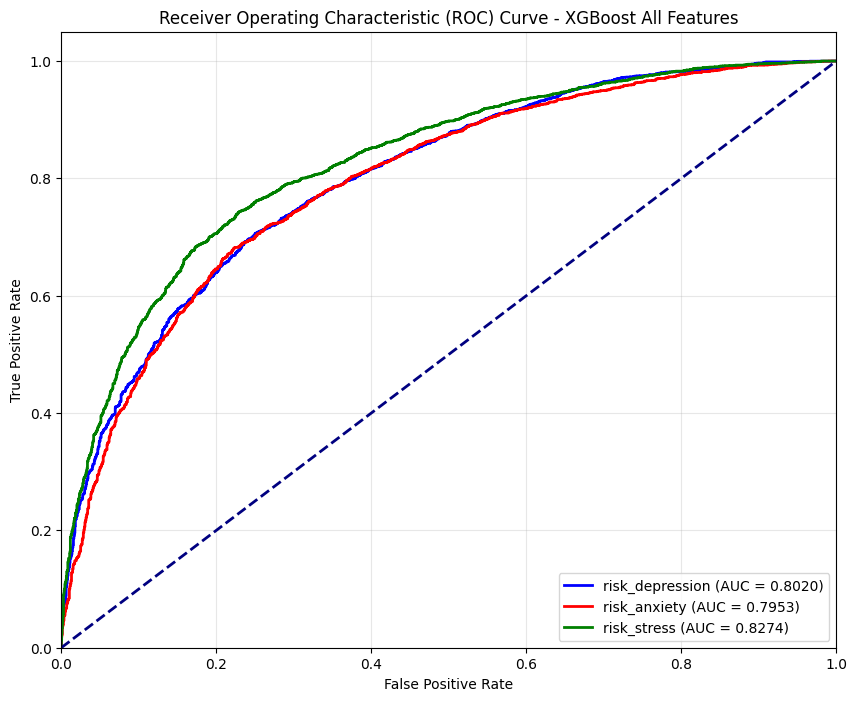

In [4]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve

# =============================================
# 11. EVALUASI ROC-AUC
# =============================================
# Mengambil probabilitas prediksi dari ClassifierChain
n_samples = X_test.values.shape[0]
n_targets = len(target_cols)
y_pred_proba = np.zeros((n_samples, n_targets))

X_aug = X_test.values.copy()
for i, estimator in enumerate(chain_model.estimators_):
    proba = estimator.predict_proba(X_aug)[:, 1]
    y_pred_proba[:, i] = proba
    pred_label = (proba >= optimal_thresholds[i]).astype(int).reshape(-1, 1)
    X_aug = np.hstack([X_aug, pred_label])

print("=" * 55)
print("📈 ROC-AUC SCORE EVALUATION")
print("=" * 55)

roc_auc_scores = {}
for i, target_name in enumerate(target_cols):
    score = roc_auc_score(y_test.values[:, i], y_pred_proba[:, i])
    roc_auc_scores[target_name] = score
    print(f"ROC-AUC {target_name:<20}: {score:.4f}")

macro_roc_auc = np.mean(list(roc_auc_scores.values()))
print("-" * 55)
print(f"Macro Average ROC-AUC     : {macro_roc_auc:.4f}")
print("=" * 55)

# Visualisasi Kurva ROC
plt.figure(figsize=(10, 8))
colors = ['blue', 'red', 'green']
for i, target_name in enumerate(target_cols):
    fpr, tpr, _ = roc_curve(y_test.values[:, i], y_pred_proba[:, i])
    plt.plot(fpr, tpr, color=colors[i], lw=2, label=f"{target_name} (AUC = {roc_auc_scores[target_name]:.4f})")

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - XGBoost All Features')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()
